# EDA – Dimensión País (dim_pais)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

df_pais = pd.read_csv("../../data/clean/dim_pais.csv",
                      encoding="utf-8-sig",
                      dtype=str,
                      keep_default_na=False,
                      na_filter=False
                      )

df_pais["lat"] = pd.to_numeric(df_pais["lat"], errors="coerce")
df_pais["lon"] = pd.to_numeric(df_pais["lon"], errors="coerce")

## Diccionario de variables (resumen)

In [10]:
df_pais.head()

,pais,id_pais,lat,lon
0,afghanistan,AF,33.933928,67.680767
1,aland islands,AX,60.197676,20.166165
2,albania,AL,41.153015,20.160672
3,argelia,DZ,28.028974,1.665444
4,american samoa,AS,-12.710816,-170.254483


## Tipo de dato y nulos

In [2]:
# Información general
df_pais.info()

# Tabla estructurada tipo diccionario de datos
eda_structure = pd.DataFrame({
    "Column Name": df_pais.columns,
    "Data Type": df_pais.dtypes.values,
    "NULLs allowed": ["Y" if df_pais[c].isna().any() else "N" for c in df_pais.columns],
    "NULL %": [round(df_pais[c].isna().mean()*100, 2) for c in df_pais.columns]
})

eda_structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   pais     249 non-null    object 
 1   id_pais  249 non-null    object 
 2   lat      249 non-null    float64
 3   lon      249 non-null    float64
dtypes: float64(2), object(2)
memory usage: 7.9+ KB


,Column Name,Data Type,NULLs allowed,NULL %
0,pais,object,N,0.0
1,id_pais,object,N,0.0
2,lat,float64,N,0.0
3,lon,float64,N,0.0


In [4]:
df_pais["pais"].str.len().max()

np.int64(44)

In [5]:
df_pais["id_pais"].str.len().max()

np.int64(2)

In [8]:
df_pais["lat"].min()
df_pais["lat"].max()

np.float64(79.98030456250001)

In [9]:
df_pais["lon"].min()
df_pais["lon"].max()

np.float64(177.965053256326)

In [6]:
df_pais["lat"].astype(str).str.split(".").str[1].str.len().max()

np.int64(16)

In [7]:
df_pais["lon"].astype(str).str.split(".").str[1].str.len().max()

np.int64(16)

1) Longitud de variables tipo texto
El análisis de longitud máxima arrojó los siguientes resultados:
pais → longitud máxima observada: 44 caracteres
id_pais → longitud máxima observada: 2 caracteres
El campo id_pais corresponde a un código ISO-2, por lo que su longitud fija de 2 caracteres confirma su modelado como CHAR(2).
El nombre del país presenta una longitud máxima de 44 caracteres, lo que indica que cualquier definición tipo VARCHAR(60) o superior sería suficiente.
2) Los valores observados fueron:
Latitud máxima ≈ 79.98
Longitud máxima ≈ 177.96
Esto confirma que:
Latitud se mantiene dentro del rango [-90, 90]
Longitud se mantiene dentro del rango [-180, 180]
El análisis mostró hasta 16 decimales en latitud y longitud.
Dado el rango y naturaleza de los datos:
Una precisión de 6 decimales es suficiente para análisis turístico.
6 decimales equivalen a una precisión aproximada de 10 cm.
Es más que adecuado para cálculos de distancia entre países. Lo cual permite valores hasta ±999.999999
Cubre completamente el rango geográfico global
Optimiza almacenamiento frente a usar 16 decimales innecesarios

In [56]:
df_pais[df_pais["pais"].str.lower().eq("namibia")][["pais","id_pais","lat","lon"]]
df_pais[df_pais["id_pais"].isna()]

,pais,id_pais,lat,lon


Tras la fase de limpieza y validación, la dimensión país presenta integridad completa en sus atributos clave. No se identifican valores nulos en el identificador ISO2 (id_pais) ni en las coordenadas geográficas (lat, lon), garantizando consistencia referencial y viabilidad para el cálculo de distancias internacionales.

## Validación estructural del modelo (PK/FK)

In [12]:
total = df_pais.shape[0]
nulos = df_pais["id_pais"].isna().sum()
duplicados = df_pais["id_pais"].duplicated().sum()
unicos = df_pais["id_pais"].nunique()

print("Total registros:", total)
print("Nulos en PK:", nulos)
print("Duplicados en PK:", duplicados)
print("Valores únicos:", unicos)


Total registros: 249
Nulos en PK: 0
Duplicados en PK: 0
Valores únicos: 249


In [13]:
if nulos == 0 and duplicados == 0 and unicos == total:
    print("✅ id_pais es válido como Primary Key")
else:
    print("❌ id_pais NO cumple condiciones de Primary Key")

✅ id_pais es válido como Primary Key


## Distribución geográfica global

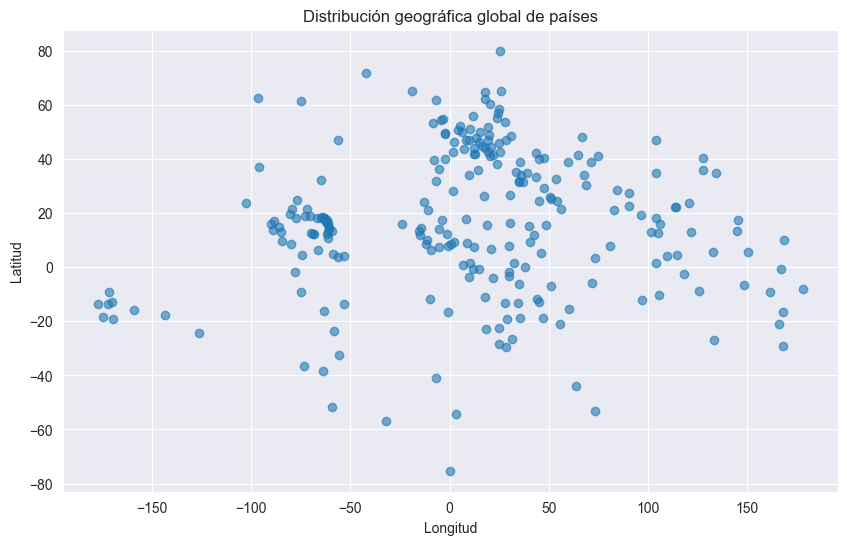

In [57]:
plt.figure(figsize=(10,6))
plt.scatter(df_pais["lon"], df_pais["lat"], alpha=0.6)
plt.title("Distribución geográfica global de países")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.grid(True)
plt.show()

Se observa:
Mayor concentración de puntos entre latitudes 30° y 60° Norte
Alta densidad en Europa y Asia
Distribución más dispersa en el hemisferio sur
Concentración moderada en África y América Latina
Puntos extremos cercanos a ±80° (países con territorios muy septentrionales)
Esto confirma que el dataset:
Tiene cobertura global
No presenta sesgo geográfico evidente
Incluye países de todos los continentes

## Clasificación por hemisferio

Conteo por hemisferio:
 hemisferio
Norte    187
Sur       62
Name: count, dtype: int64

Proporción (%):
 hemisferio
Norte    75.1
Sur      24.9
Name: proportion, dtype: float64


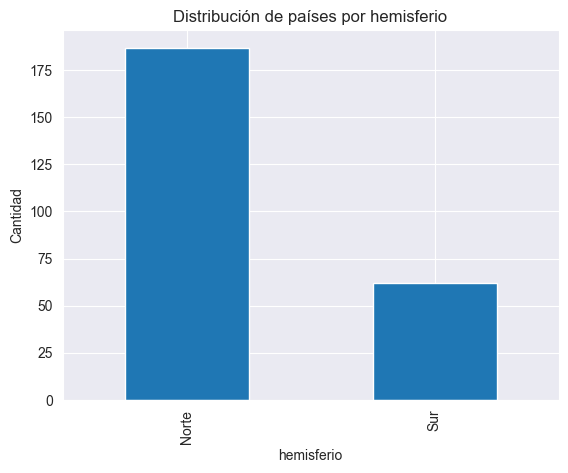

In [58]:
df_pais["hemisferio"] = np.where(df_pais["lat"] >= 0, "Norte", "Sur")

hemisferio_counts = df_pais["hemisferio"].value_counts()
hemisferio_prop = df_pais["hemisferio"].value_counts(normalize=True) * 100

print("Conteo por hemisferio:\n", hemisferio_counts)
print("\nProporción (%):\n", hemisferio_prop.round(2))

hemisferio_counts.plot(kind="bar")
plt.title("Distribución de países por hemisferio")
plt.ylabel("Cantidad")
plt.show()

Conteo:
Hemisferio Norte: 187 países
Hemisferio Sur: 62 países
Proporción:
Norte: 75.1%
Sur: 24.9%

La visualización geoespacial confirma una distribución heterogénea de países a nivel global, con mayor concentración en el hemisferio norte, especialmente en Europa y Asia. Este patrón es consistente con la distribución geopolítica mundial y valida la cobertura internacional del dataset. La dispersión observada respalda la viabilidad del cálculo de distancias desde múltiples regiones hacia España. El análisis hemisférico muestra que el 75.1% de los países del dataset se ubican en el hemisferio norte, mientras que el 24.9% se localizan en el hemisferio sur. Este patrón es coherente con la distribución geopolítica global y refuerza el posicionamiento estratégico de España dentro del hemisferio norte como destino turístico internacional. Asimismo, esta clasificación permite introducir variables contextuales relacionadas con estacionalidad, distancia y esfuerzo de desplazamiento.

## Cálculo de distancia a España (Haversine)

In [59]:
# Primero obtenemos coordenadas de España
esp = df_pais[df_pais["id_pais"] == "ES"]
lat_es = float(esp["lat"].iloc[0])
lon_es = float(esp["lon"].iloc[0])

In [60]:
# Funcion Haversine
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # radio tierra km

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arcsin(np.sqrt(a))

    return R * c

In [61]:
# Aplicar distancia
df_pais["distancia_km"] = df_pais.apply(
    lambda row: haversine(row["lat"], row["lon"], lat_es, lon_es),
    axis=1
)
df_pais[["pais", "distancia_km"]].head()

,pais,distancia_km
0,afghanistan,6112.362818
1,aland islands,2747.241226
2,albania,1913.912989
3,argelia,1373.510325
4,american samoa,16763.274092


## Ranking países más cercanos y más lejanos

In [62]:
df_sorted = df_pais.sort_values("distancia_km")

print("🔹 Países más cercanos a España:")
display(df_sorted.head(10)[["pais", "distancia_km"]])

print("\n🔹 Países más lejanos a España:")
display(df_sorted.tail(10)[["pais", "distancia_km"]])

🔹 Países más cercanos a España:


,pais,distancia_km
208,españa,0.000000
5,andorra,450.963526
177,portugal,459.683320
84,gibraltar,487.951975
75,francia,800.362944
146,monaco,924.984240
150,marruecos,991.153056
112,jersey,1036.330544
91,guernsey,1075.744394
215,suiza,1156.533669



🔹 Países más lejanos a España:


,pais,distancia_km
230,tuvalu,16492.288396
52,cook islands,16531.674924
4,american samoa,16763.274092
191,samoa,16935.777100
244,wallis and futuna,17063.439705
239,vanuatu,17280.100585
162,niue,17401.542940
224,tonga,17525.255884
157,new caledonia,17652.074624
163,norfolk island,18524.579543


## Agrupación por rangos de distancia

In [63]:
bins = [0, 2000, 5000, 10000, 20000]
labels = ["Muy cercanos", "Cercanos", "Intermedios", "Lejanos"]

df_pais["grupo_distancia"] = pd.cut(df_pais["distancia_km"], bins=bins, labels=labels)

df_pais["grupo_distancia"].value_counts()

grupo_distancia
Intermedios     104
Cercanos         64
Lejanos          47
Muy cercanos     33
Name: count, dtype: int64

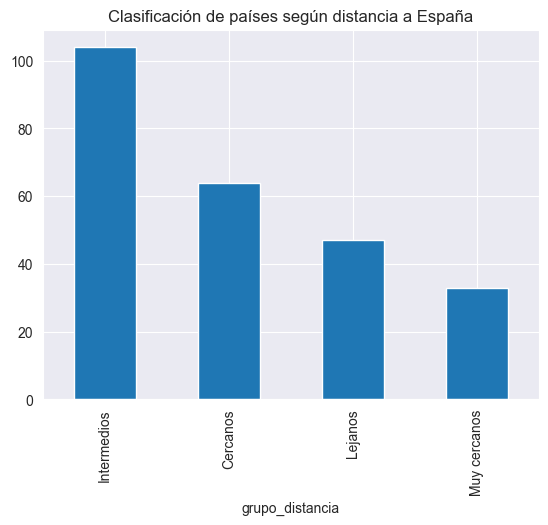

In [64]:
df_pais["grupo_distancia"].value_counts().plot(kind="bar")
plt.title("Clasificación de países según distancia a España")
plt.show()

## Validación de integridad geoespacial

In [65]:
print("Nulos lat:", df_pais["lat"].isna().sum())
print("Nulos lon:", df_pais["lon"].isna().sum())

# Rango válido aproximado planeta
fuera_rango = df_pais[
    (df_pais["lat"] < -90) | (df_pais["lat"] > 90) |
    (df_pais["lon"] < -180) | (df_pais["lon"] > 180)
]

print("Registros fuera de rango:", fuera_rango.shape[0])

Nulos lat: 0
Nulos lon: 0
Registros fuera de rango: 0


## Preparación para Feature Engineering

In [66]:
features_identificadas = [
    "distancia_km",
    "grupo_distancia",
    "hemisferio"
]

features_identificadas

['distancia_km', 'grupo_distancia', 'hemisferio']